(10886, 12)
0
0


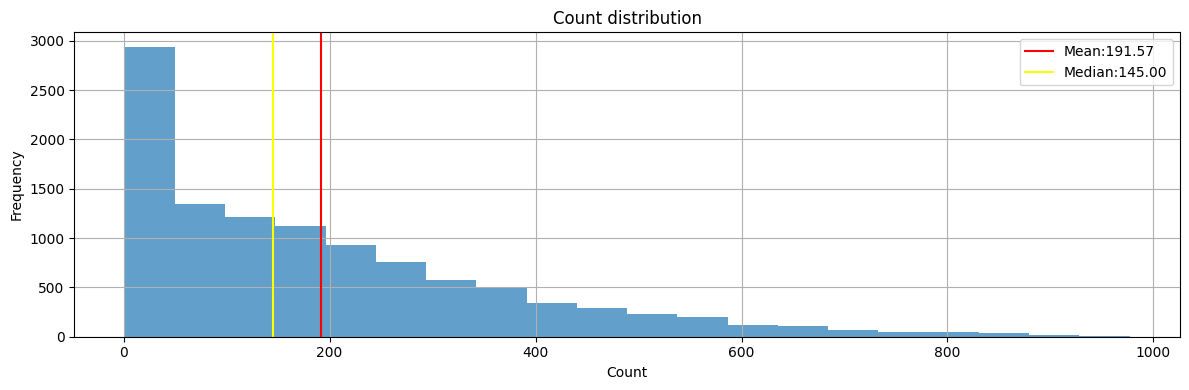

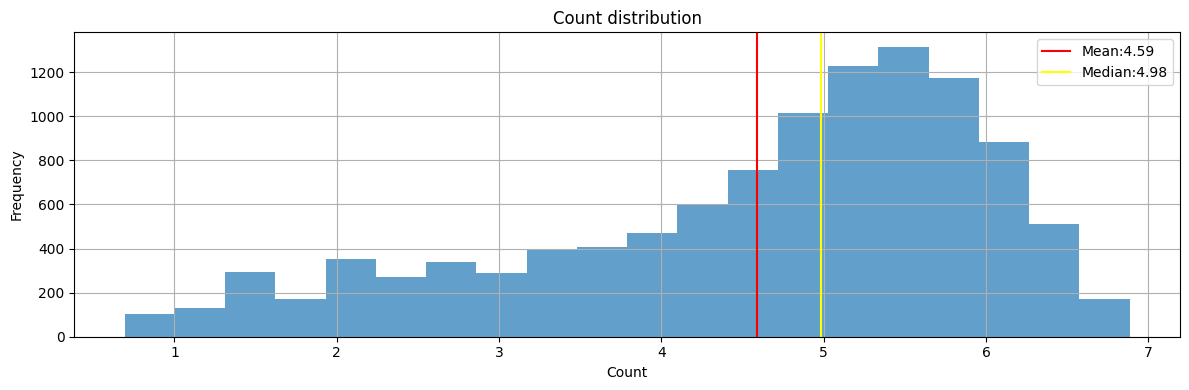

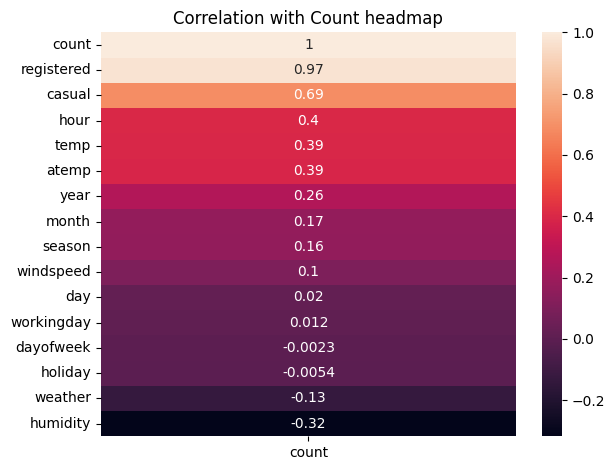

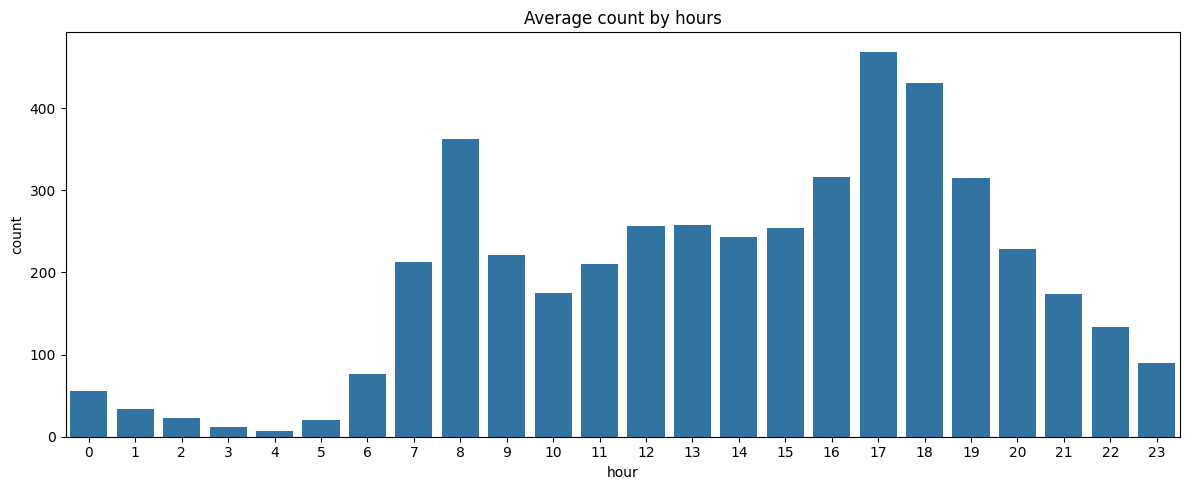

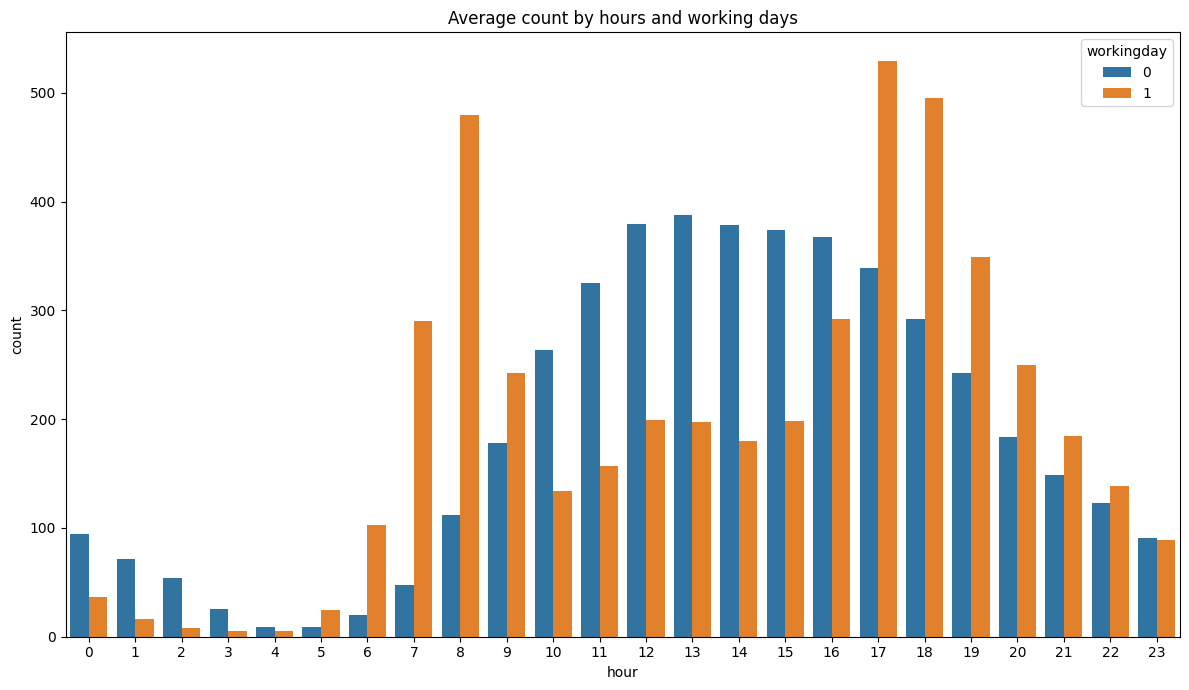

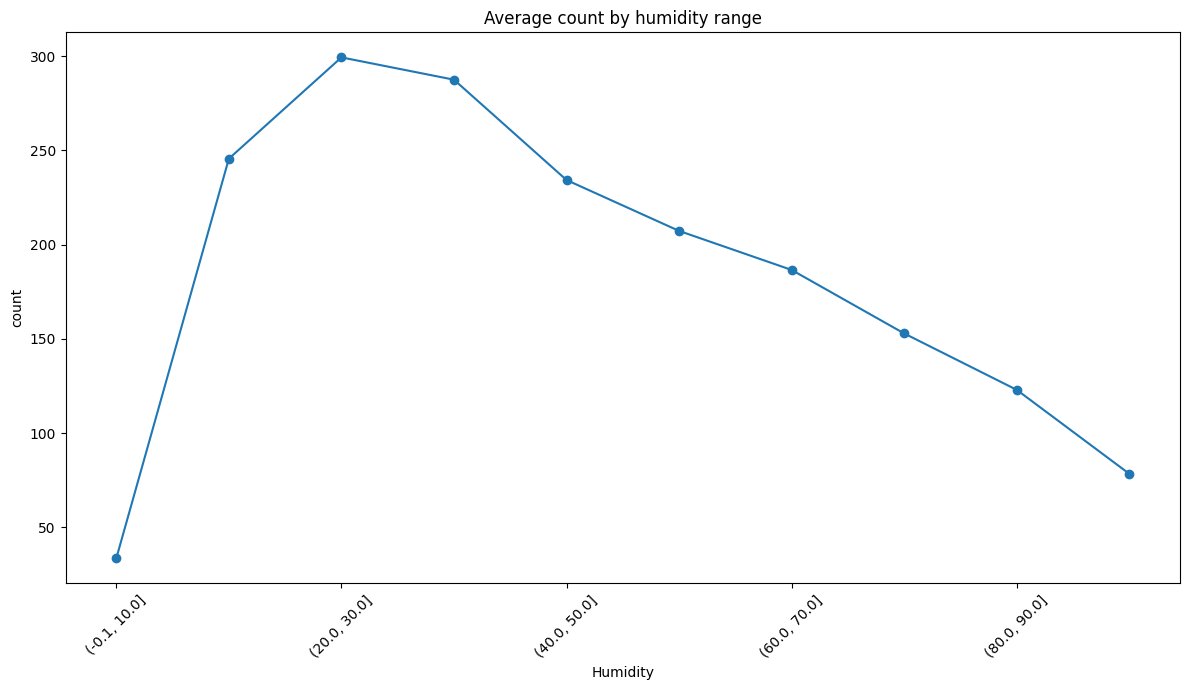

Temp-count corr high humidity: 0.184
Temp-count corr low humidity:  0.466


In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_train = pd.read_csv('../data/bike_sharing_demand_train.csv')
df_test =  pd.read_csv('../data/bike_sharing_demand_test.csv')
print(df_train.shape)
print(df_train.isnull().sum().sum())
print(df_test.isnull().sum().sum())


# check distribution of target variable

def plot_distribution():
    plt.figure(figsize=(12,4))
    df_train['count'].hist(bins=20,alpha=0.7)
    plt.axvline( df_train['count'].mean(), color='red', label=f"Mean:{df_train['count'].mean():.2f}")
    plt.axvline( df_train['count'].median(), color='yellow', label=f"Median:{df_train['count'].median():.2f}")
    plt.title('Count distribution')
    plt.xlabel('Count')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Check skewness of target variable
plot_distribution()

# target variable is right skewed, so apply log transformation
df_train['count'] = df_train['count'].apply(lambda x: np.log1p(x))

# save test datetime and target variables
y = df_train['count']
date_times = df_test['datetime'].copy()

plot_distribution()


def extract_time(df:pd.DataFrame):
    df['datetime'] = pd.to_datetime(df['datetime'])
    df['hour'] = df['datetime'].dt.hour
    df['month'] = df['datetime'].dt.month
    df['day'] = df['datetime'].dt.day
    df['year'] = df['datetime'].dt.year
    df['dayofweek'] = df['datetime'].dt.dayofweek

    df = df.drop(columns=['datetime'],errors="ignore")
    
    return df

""" EDA """
df_eda =  pd.read_csv('../data/bike_sharing_demand_train.csv')
# check correlation

# Convert datetime to hour,month,year and day of week before checking correlation
df_eda = extract_time(df_eda)

correlation = df_eda.corr()[['count']].sort_values(by='count',ascending=False)
sns.heatmap(correlation,annot=True)
plt.title('Correlation with Count headmap')
plt.tight_layout()
plt.show()


# count by hour (hour has the highest corr with Count , registered + casual = count , so doesnt count as a feature)
plt.figure(figsize=(12,5))
count_by_hour = df_eda.groupby('hour')['count'].mean().reset_index()
sns.barplot(data=count_by_hour,x='hour',y='count')
plt.title('Average count by hours')
plt.tight_layout()
plt.show()

# count by hour for working days
plt.figure(figsize=(12,7))
count_by_working_days_hour = df_eda.groupby(['hour','workingday'])['count'].mean().reset_index()
sns.barplot(data=count_by_working_days_hour,x='hour',y='count',hue='workingday')
plt.title('Average count by hours and working days')
plt.tight_layout()
plt.show()

# count by humidity
df_eda['humidity_bin'] = pd.cut(df_eda['humidity'], bins=10)
plt.figure(figsize=(12,7))
df_eda.groupby('humidity_bin')['count'].mean().plot(kind='line', marker='o')
plt.title('Average count by humidity range')
plt.xlabel('Humidity')
plt.ylabel('count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


high_hum = df_eda[df_eda['humidity'] > 70]
low_hum  = df_eda[df_eda['humidity'] <= 70]

print(f"Temp-count corr high humidity: {high_hum['temp'].corr(high_hum['count']):.3f}")
print(f"Temp-count corr low humidity:  {low_hum['temp'].corr(low_hum['count']):.3f}")



In [75]:
""" Preprocess data """

# combine test and train data before preprocessing

len_df_train = len(df_train)

# remove casual and registered before combining , since adding them equals target variable
df_train = df_train.drop(columns=['casual','registered','count'],errors='ignore').copy()
combined_df = pd.concat([df_train,df_test],axis=0).reset_index(drop=True)


# check null columns in combined_df
null_columns = combined_df.isnull().sum().sum()
print("isNull",null_columns)


""" Feature engineering """

# extract time
combined_df = extract_time(combined_df)


# create new features

rush_hours = [7,8,9,16,17,18,19]
night_hours = [0,1,2,3,4,5]
leisure_peak_hours = [10,11,12,13,14,15]

combined_df['is_rush_hour'] =  combined_df['hour'].isin(rush_hours).astype(int)
combined_df['is_night'] = combined_df['hour'].isin(night_hours).astype(int)
combined_df['is_leisure_peak'] = combined_df['hour'].isin(leisure_peak_hours).astype(int)
combined_df['rush_hour_workingday'] = combined_df['is_rush_hour'] * combined_df['workingday']
combined_df['is_high_humidity'] = (combined_df['humidity'] > 70).astype(int)
combined_df['is_optimal_humidity'] = ((combined_df['humidity'] >= 20) & (combined_df['humidity'] <= 60)).astype(int)
combined_df['temp_humidity'] = combined_df['temp'] * combined_df['humidity']
combined_df['hour_season']    = combined_df['hour'] * combined_df['season']
combined_df['temp_season']    = combined_df['temp'] * combined_df['season']
combined_df['hour_workingday']= combined_df['hour'] * combined_df['workingday']
combined_df['temp_windspeed'] = combined_df['temp'] * combined_df['windspeed']
combined_df['humidity_season']   = combined_df['humidity'] * combined_df['season']
combined_df['hour_temp']         = combined_df['hour'] * combined_df['temp']
combined_df['hour_humidity']     = combined_df['hour'] * combined_df['humidity']
combined_df['workingday_season'] = combined_df['workingday'] * combined_df['season']
combined_df['weather_temp']      = combined_df['weather'] * combined_df['temp']

""" Check skewness """
def get_skewness():
    # Only check truly continuous numeric columns
    skip_cols = ['holiday', 'rush_hour_workingday', 'weather', 'is_night',
             'is_leisure_peak', 'is_rush_hour', 'workingday', 'season',
             'month', 'hour', 'day', 'year', 'dayofweek','is_high_humidity','is_optimal_humidity']

    numeric_cols = [c for c in combined_df.select_dtypes(include='number').columns
                if c not in skip_cols]

    skewness = combined_df[numeric_cols].skew().sort_values(ascending=False)
    return skewness

 # Filter to highly skewed
skewness = get_skewness()
high_skew = skewness[skewness.abs() > 0.75].index.tolist()
combined_df[high_skew] = combined_df[high_skew].apply(lambda x: np.log1p(x))


""" Encoding """
cat_cols = combined_df.select_dtypes(include='object').columns.tolist()
cols_to_encode = cat_cols + ['season', 'weather']
combined_df = pd.get_dummies(data=combined_df, columns=cols_to_encode, drop_first=True,dtype=int)

# Split back
train_encoded = combined_df.iloc[:len_df_train].copy()
test_encoded = combined_df.iloc[len_df_train:].copy()

print(f"train encoded shape:{train_encoded.shape}")
print(f"test encoded shape:{test_encoded.shape}")

isNull 0
train encoded shape:(10886, 33)
test encoded shape:(6493, 33)


In [76]:
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_log_error,r2_score,make_scorer

""" Fitting Train data"""
X = train_encoded

tscv = TimeSeriesSplit(n_splits=10)

# Get the last fold as your train/test split
for train_idx, test_idx in tscv.split(X):
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

# Using XGBoost XGBRegressor
xgb_model = XGBRegressor(n_estimators=200,max_depth=4,learning_rate=0.1,random_state=42, verbosity=0)

xgb_model.fit(X_train,y_train)

# predict
y_pred_train = xgb_model.predict(X_train)
y_pred_test = xgb_model.predict(X_test)

def get_model_scores(y_input,y_pred):
    y_input_real = np.expm1(y_input)   # reverse log on y_train or y_test
    y_pred_real  = np.expm1(y_pred)    # reverse log on predictions
    rmsle = root_mean_squared_log_error(y_input_real, y_pred_real)
    r2   = r2_score(y_input_real, y_pred_real)
    return rmsle,r2

train_rmsle,train_r2 = get_model_scores(y_train,y_pred_train)
test_rmsle,test_r2 = get_model_scores(y_test,y_pred_test)


print(f"Train RMSLE: {train_rmsle:.4f}")
print(f"Train R²:   {train_r2:.4f}")

print(f"Test RMSLE: {test_rmsle:.4f}")
print(f"Test R²:   {test_r2:.4f}")

# cross validation score

def rmsle_real(y_true, y_pred):
    return root_mean_squared_log_error(
        np.expm1(y_true),
        np.expm1(y_pred)
    )

rmsle_scorer = make_scorer(rmsle_real, greater_is_better=False)

cv = cross_val_score(xgb_model,X_train,y_train,scoring=rmsle_scorer,cv=tscv, n_jobs=-1)
print(f"CV RMSE scores: {(-cv).round(4)}")
print(f"CV mean and std:{(-cv).mean():.3f} ± {(-cv).std():.3f}")


Train RMSLE: 0.2488
Train R²:   0.9580
Test RMSLE: 0.3036
Test R²:   0.9199
CV RMSE scores: [0.6362 0.6031 0.3174 0.4381 0.326  0.7623 0.4043 0.3615 0.272  0.336 ]
CV mean and std:0.446 ± 0.156


In [77]:
"""Tune XGBRegressor"""

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import uniform, randint

param_grid = {
    'n_estimators':  [200, 300, 500],
    'max_depth':     [3, 4, 5, 6],
    'learning_rate': [0.05, 0.1, 0.15],
    'subsample':     [0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

param_grid_narrow = {
    'n_estimators':     [400, 500, 600],
    'max_depth':        [3, 4, 5],
    'learning_rate':    [0.07, 0.08, 0.09, 0.1],
    'subsample':        [0.75, 0.8, 0.85],
    'colsample_bytree': [0.85, 0.9, 0.95],
    'min_child_weight': [3, 5, 7],
}

# param_distributions = {
#     'n_estimators':     randint(100, 1000),      # any int 100-1000
#     'max_depth':        randint(3, 10),           # any int 3-10
#     'learning_rate':    uniform(0.01, 0.2),       # any float 0.01-0.21
#     'subsample':        uniform(0.6, 0.4),        # any float 0.6-1.0
#     'colsample_bytree': uniform(0.6, 0.4),
#     'min_child_weight': randint(1, 10)
# }

grid_search = GridSearchCV(estimator=XGBRegressor(random_state=42,verbosity=0), param_grid=param_grid, cv=tscv, scoring=rmsle_scorer, n_jobs=-1)
grid_search.fit(X,y)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {-(grid_search.best_score_):.3f}")

# Create fresh model with best params
best_model_eval = XGBRegressor(
    **grid_search.best_params_,
    random_state=42,
    verbosity=0
)
best_model_eval.fit(X_train, y_train)
y_pred = best_model_eval.predict(X_test)

best_model_rmsle, best_model_r2 = get_model_scores(y_test, y_pred)
print(f"Test RMSLE: {best_model_rmsle:.4f}")
print(f"Test R²:    {best_model_r2:.4f}")

Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 500, 'subsample': 0.8}
Best cross-validation accuracy: 0.393
Test RMSLE: 0.3019
Test R²:    0.9266


In [78]:
# refit on full train data before predicting on test data

final_model = XGBRegressor(**grid_search.best_params_, random_state=42, verbosity=0)
final_model.fit(X, y)


test_preds_log = final_model.predict(test_encoded)
test_preds     = np.expm1(test_preds_log)


# create submission
final_submission = pd.DataFrame({
    'datetime': date_times,
    'count':np.round(test_preds).astype(int)
})

final_submission.to_csv('outputs/bike_sharing_demand_submission.csv', index=False)

In [79]:
import joblib 

# Save model
joblib.dump(final_model, 'outputs/kaggle_bike_sharing_demand_model.pkl')

['outputs/kaggle_bike_sharing_demand_model.pkl']